[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/information_theory/01_self_information_and_entropy/first_principles.ipynb)

# Module 01 — Self-Information and Entropy

## 1. Why This Module Exists

Two messages arrive. "The sun rose this morning" changes nothing you will do today; "your
ticket won the lottery" changes everything.

Both are one sentence long. What separates them is not length but probability, and every
result below grows out of turning that observation into a number.

This module fixes the number. Demand three innocuous properties — certainty carries no
information, rarer is more surprising, independent surprises add — and the measure of surprise
is forced to be $-\log p$, with nothing left to choose but the base of the logarithm.

Averaging that quantity over a source gives the **entropy** $H(X)$. Entropy is not a definition
looking for a use: it is the exact number of bits per symbol below which no lossless code can
go, which is why the same formula sets the floor of a cross-entropy loss, the impurity of a
decision-tree split, and the thermodynamic cost of erasing a bit.

## 2. Intuition

Picture a source as a machine emitting symbols, and a code as a machine writing each symbol
down in binary.

A frequent symbol deserves a short codeword and a rare one a long codeword. The only question
is how long, and the answer is $\log_2(1/p)$ bits: a symbol appearing once in eight times is
worth three bits.

Entropy is the average of those ideal lengths taken under the source's own distribution. Two
extremes bracket everything else — a source that always emits the same symbol costs nothing,
$H = 0$; a source uniform on $K$ symbols is the hardest of its size, $H = \log_2 K$.

The picture to carry is the **binary entropy curve**. Plot $H_b(p)$ against the bias $p$ of a
coin: it vanishes at both ends, rises to exactly one bit at $p = \tfrac{1}{2}$, and is concave
throughout.

That concavity is not decoration. It is the geometric form of the statement that blending two
sources cannot make the blend more predictable than the average of its parts, which is
Theorem 4.5.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single
random generator used everywhere below, and prints the machine epsilon against which every
later residual is measured.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")


def H_bits(p):
    """Shannon entropy in bits, with the convention 0 log 0 = 0."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0.0]
    return float(-(p * np.log2(p)).sum() + 0.0)


def H_nats(p):
    """Shannon entropy in nats, with the convention 0 log 0 = 0."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0.0]
    return float(-(p * np.log(p)).sum() + 0.0)


print("H(1/2, 1/4, 1/8, 1/8) =", H_bits([0.5, 0.25, 0.125, 0.125]), "bits")

machine epsilon = 2.2204e-16
H(1/2, 1/4, 1/8, 1/8) = 1.75 bits


Every residual reported later is quoted as a multiple of this machine epsilon. The two helper
functions implement Definition 3.2 in the two units used throughout.

The next cell draws the mandatory picture of this module: the binary entropy function
$H_b(p)$ on $[0, 1]$, with its maximum marked, together with the chord joining
$(0.1, H_b(0.1))$ to $(0.9, H_b(0.9))$. The curve lying above its own chord is concavity made
visible.

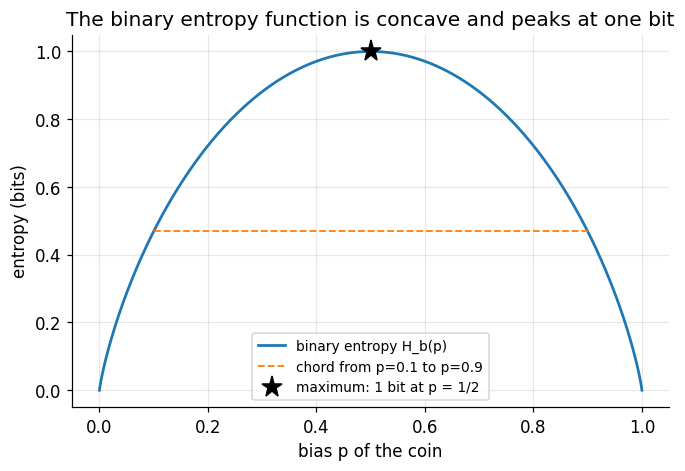

H_b(0.50) = 1.0 bits
H_b(0.40) = 0.9709505944546686 bits   cost of moving 0.5 -> 0.4 : 0.02904940554533142
H_b(0.10) = 0.4689955935892812 bits
H_b(0.01) = 0.08079313589591118 bits   cost of moving 0.1 -> 0.01: 0.38820245769337003
curve above chord everywhere: True


In [2]:
def Hb_of(x):
    """Binary entropy in bits, for a scalar bias in (0, 1)."""
    return float(-x * np.log2(x) - (1 - x) * np.log2(1 - x))


pgrid = np.linspace(1e-9, 1.0 - 1e-9, 1200)
Hb = -pgrid * np.log2(pgrid) - (1 - pgrid) * np.log2(1 - pgrid)

pa, pb = 0.1, 0.9
Ha, Hbb = Hb_of(pa), Hb_of(pb)

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.plot(pgrid, Hb, lw=1.8, label="binary entropy H_b(p)")
ax.plot([pa, pb], [Ha, Hbb], lw=1.2, ls="--", label="chord from p=0.1 to p=0.9")
ax.plot([0.5], [1.0], "k*", ms=14, label="maximum: 1 bit at p = 1/2")
ax.set_xlabel("bias p of the coin")
ax.set_ylabel("entropy (bits)")
ax.set_title("The binary entropy function is concave and peaks at one bit")
ax.legend(loc="lower center", fontsize=9)
plt.show()

print("H_b(0.50) =", Hb_of(0.50), "bits")
print("H_b(0.40) =", Hb_of(0.40), "bits   cost of moving 0.5 -> 0.4 :", Hb_of(0.50) - Hb_of(0.40))
print("H_b(0.10) =", Hb_of(0.10), "bits")
print("H_b(0.01) =", Hb_of(0.01), "bits   cost of moving 0.1 -> 0.01:", Hb_of(0.10) - Hb_of(0.01))
print("curve above chord everywhere:",
      bool(np.all(Hb[(pgrid >= pa) & (pgrid <= pb)]
                  >= np.interp(pgrid[(pgrid >= pa) & (pgrid <= pb)],
                               [pa, pb], [Ha, Hbb]) - 1e-12)))

The peak sits at exactly one bit, and the curve never dips below the dashed chord: entropy is
concave in the distribution.

Note how flat the curve is near the top. Moving the bias from $0.5$ to $0.4$ costs only
$0.0290$ bits, whereas moving it from $0.1$ to $0.01$ costs $0.3882$ bits — uncertainty is
insensitive near maximum and violently sensitive near certainty.

## 3. Definitions

Throughout, $X$ is a random variable on a countable alphabet $\mathcal{X}$ with probability
mass function $p$, and

$$
\operatorname{supp}(p) = \{ x \in \mathcal{X} : p(x) \gt 0 \}, \qquad K = \lvert \operatorname{supp}(p) \rvert .
$$

Symbol conventions follow [the notation register](../../docs/notation.md). Two rulings matter
here: $H$ with two random-variable arguments is *joint* entropy, never cross-entropy, and every
numerical answer carries its unit — **bits** for $\log_2$, **nats** for $\ln$. A bare $\log$
appears only in statements where the base cancels.

### Definition 3.1 — Self-information

For an outcome $x$ with $p(x) \gt 0$, the **self-information** (or surprisal) of $x$ in base
$b$ is

$$
I_b(x) = -\log_b p(x) = \log_b \frac{1}{p(x)} .
$$

Base $2$ gives **bits**, base $e$ gives **nats**, base $10$ gives **hartleys**, and the three
differ only by a constant factor: $I_e(x) = I_2(x) \ln 2$.

The restriction $p(x) \gt 0$ is not cosmetic. An impossible outcome has no finite surprisal,
and Definition 3.2 handles it by a limit rather than by evaluating $\log 0$.

### Definition 3.2 — Shannon entropy

The **Shannon entropy** of $X$ is the expected self-information,

$$
H(X) = \mathbb{E}\left[-\log p(X)\right] = -\sum_{x \in \operatorname{supp}(p)} p(x) \log p(x),
$$

with the convention $0 \log 0 = 0$, justified by $\lim_{t \to 0^{+}} t \log t = 0$.

Entropy depends on the distribution alone, not on the labels of the outcomes, so we also write
$H(p)$ for the entropy of a probability vector $p = (p_1, \dots, p_K)$.

### Definition 3.3 — Binary entropy function

For $p \in [0, 1]$,

$$
H_b(p) = -p \log_2 p - (1-p) \log_2 (1-p) \quad \text{bits},
$$

with $H_b(0) = H_b(1) = 0$ by the same convention. This is the entropy of a single biased coin.

### Definition 3.4 — Differential entropy

For a random variable $X$ with density $f$ on $\mathcal{S} \subseteq \mathbb{R}$, the
**differential entropy** is

$$
h(X) = -\int_{\mathcal{S}} f(x) \ln f(x) \, dx \quad \text{nats},
$$

whenever the integral exists.

Despite the name, $h$ is not the continuous limit of $H$: it may be negative, and it moves
under rescaling, $h(aX) = h(X) + \ln \lvert a \rvert$. Section 7 exhibits both failures.

### Definition 3.5 — Relative entropy

For distributions $p, q$ on the same alphabet with $q(x) = 0 \Rightarrow p(x) = 0$, the
**relative entropy** (Kullback-Leibler divergence) is

$$
D_{\mathrm{KL}}(p \parallel q) = \sum_{x \in \operatorname{supp}(p)} p(x) \log \frac{p(x)}{q(x)} .
$$

The continuous version replaces the sum by $\int f \ln (f/g)$.

It appears here only as a tool: Lemma 4.1 proves the one fact about it that this module needs,
and [Module 04](../04_kl_divergence_and_f_divergences/) develops it and its $f$-divergence
generalizations in full.

### Definition 3.6 — Prefix code and expected length

A **$D$-ary code** assigns to each $x \in \mathcal{X}$ a finite string $C(x)$ over an alphabet
of $D$ symbols, of length $\ell(x)$. The code is a **prefix code** (equivalently
*instantaneous*) when no codeword is a prefix of another.

Its **expected length** is

$$
\mathbb{E}[L] = \sum_{x} p(x)\, \ell(x) .
$$

Prefix-freeness is what makes a stream decodable symbol by symbol with no lookahead, and
Theorem 4.8 shows it costs exactly one constraint on the lengths and nothing more.

### Definition 3.7 — Typical set

Let $X_1, \dots, X_n$ be i.i.d. with pmf $p$ on a finite alphabet and entropy $H$ in nats. For
$\epsilon \gt 0$ the **typical set** is

$$
A_{\epsilon}^{(n)} = \left\{ (x_1, \dots, x_n) : \left\lvert -\tfrac{1}{n}\ln p(x_1, \dots, x_n) - H \right\rvert \le \epsilon \right\} .
$$

It is the set of sequences whose own probability is close to $e^{-nH}$ on the exponential
scale — not the most likely sequences, but the ones that carry essentially all the mass.

## 4. Main Results

Lemma 4.1 is the single analytic tool the module needs, and it is proved from scratch so that
nothing here depends on a later module.

Theorems 4.2 and 4.3 are the characterization results: the first forces the form of surprisal,
the second — the theorem this module is named after — forces the form of its average.
Theorems 4.4 to 4.7 are the standard properties. Theorems 4.8 to 4.10 supply the operational
meaning: entropy is a code length.

### Lemma 4.1 — Tangent-line bound and Gibbs' inequality

For every $t \gt 0$,

$$
\ln t \le t - 1,
$$

with equality if and only if $t = 1$.

Consequently, for distributions $p, q$ on a common alphabet with
$q(x) = 0 \Rightarrow p(x) = 0$,

$$
D_{\mathrm{KL}}(p \parallel q) \ge 0,
$$

with equality if and only if $p = q$. The same holds for densities, with the sum replaced by an
integral.

**Hypotheses.** Absolute continuity of $p$ with respect to $q$ is needed for the divergence to
be finite; without it the sum contains a term $p(x)\log(p(x)/0) = +\infty$, and the inequality
survives only vacuously.

Proved as Proof 5.1.

### Theorem 4.2 — Uniqueness of self-information

Let $I : (0, 1] \to [0, \infty)$ satisfy

1. $I(1) = 0$;
2. $I$ is non-increasing on $(0,1]$;
3. $I(pq) = I(p) + I(q)$ for all $p, q \in (0, 1]$.

Then there is a constant $c \ge 0$ with

$$
I(p) = -c \ln p \qquad \text{for all } p \in (0,1] .
$$

If $I$ is not identically zero then $c \gt 0$, and $c$ is exactly the choice of unit.

**Hypotheses.** Additivity is the load-bearing one: it converts the multiplicative structure of
independent probabilities into an additive structure, and multiplicative-to-additive maps are
logarithms. Monotonicity is what excludes the pathological non-measurable solutions of Cauchy's
functional equation; it can be traded for continuity, but one of the two is indispensable
(Hardy, Littlewood and Polya, *Inequalities*, 2nd ed., section 3.4). Section 7.3 runs a
continuous, monotone, non-additive candidate and shows it fails.

Proved as Proof 5.2.

### Theorem 4.3 — Shannon-Khinchin uniqueness of entropy

For each $K \ge 1$ let $H_K : \Delta_{K-1} \to \mathbb{R}$ be defined on the probability
simplex, and suppose the family satisfies

1. **Symmetry.** $H_K$ is invariant under permutation of its arguments.
2. **Continuity.** $p \mapsto H_2(p, 1-p)$ is continuous on $[0, 1]$.
3. **Monotone uniform value.** $f(K) = H_K\!\left(\tfrac{1}{K}, \dots, \tfrac{1}{K}\right)$ is
   non-decreasing in $K$ and $f(2) \gt f(1)$.
4. **Grouping (recursivity).** For every $K \ge 2$ and every $p \in \Delta_{K-1}$ with
   $w = p_{K-1} + p_K \gt 0$,

$$
H_K(p_1, \dots, p_K) = H_{K-1}(p_1, \dots, p_{K-2}, w) + w\, H_2\!\left(\frac{p_{K-1}}{w}, \frac{p_K}{w}\right).
$$

Then there is a constant $c \gt 0$ with

$$
H_K(p) = -c \sum_{k=1}^{K} p_k \log p_k \qquad \text{for every } K \text{ and every } p .
$$

**Hypotheses, one sentence each.** Symmetry says uncertainty does not depend on how the
outcomes are labelled. Continuity is what carries the conclusion from rational probabilities,
where it is proved, to all of the simplex. Monotonicity of $f$ says a larger fair die is
harder to predict, and it is what pins down the solution of the integer Cauchy equation
$f(Km) = f(K) + f(m)$; without it every solution of that equation on the primes extends
arbitrarily. Grouping says that resolving a choice in two stages costs the same as resolving it
in one, weighted by the probability of reaching the second stage — this is the axiom that does
almost all of the work.

Proved as Proof 5.3.

### Theorem 4.4 — Entropy bounds

Let $X$ have support of size $K \lt \infty$. Then

$$
0 \le H(X) \le \log K .
$$

The lower bound is attained if and only if $X$ is deterministic. The upper bound is attained if
and only if $p$ is uniform on its support, and the uniform distribution is the unique maximizer.

**Hypotheses.** Discreteness is what forces $H \ge 0$: every term $p \log (1/p)$ is
non-negative because $p \le 1$. Finiteness of $K$ is what makes the upper bound finite; on a
countably infinite alphabet entropy can be $+\infty$. If the alphabet has $N \ge K$ symbols but
only $K$ of them carry mass, the bound reads $H(X) \le \log K \le \log N$, with the sharper
constant coming from the support, not the alphabet.

Proved as Proof 5.4.

### Theorem 4.5 — Concavity of entropy

For distributions $p, q$ on a common alphabet and $\lambda \in [0,1]$,

$$
H(\lambda p + (1-\lambda) q) \ge \lambda H(p) + (1-\lambda) H(q),
$$

with equality for $\lambda \in (0,1)$ if and only if $p = q$.

**Hypotheses.** None beyond both distributions living on the same alphabet, which is what makes
the mixture a distribution at all.

**Interpretation.** Averaging two sources produces something at least as unpredictable as the
average of their unpredictabilities. Consequence: the plug-in entropy estimator is biased
*downward*, because $\hat{p}$ fluctuates around $p$ and Jensen then runs the other way.
Section 7.6 measures that bias.

Proved as Proof 5.5.

### Theorem 4.6 — Deterministic processing cannot create entropy

Let $g$ be a deterministic map on $\mathcal{X}$ and $Y = g(X)$. Then

$$
H(Y) \le H(X),
$$

with equality if and only if $g$ is injective on $\operatorname{supp}(p)$.

**Hypotheses.** Determinism is essential: a randomized $g$ can raise entropy, since adding an
independent fair coin to $X$ produces $H(X) + 1$ bit.

Proved as Proof 5.6.

### Theorem 4.7 — The Gaussian maximizes differential entropy at fixed variance

Among all densities on $\mathbb{R}$ with variance $\sigma^2 \lt \infty$, the Gaussian
$\mathcal{N}(\mu, \sigma^2)$ uniquely maximizes differential entropy, and

$$
h(X) \le \frac{1}{2}\ln\left(2\pi e \sigma^2\right) \quad \text{nats}.
$$

**Hypotheses.** The variance constraint is what makes the supremum finite; without it $h$ is
unbounded above, since $h(aX) = h(X) + \ln \lvert a \rvert$ grows without limit. The mean is
irrelevant, because $h$ is translation invariant.

Proved as Proof 5.7, using only Lemma 4.1.

### Theorem 4.8 — Kraft's inequality and its converse

Let $\ell_1, \dots, \ell_K$ be the codeword lengths of a $D$-ary prefix code. Then

$$
\sum_{k=1}^{K} D^{-\ell_k} \le 1 .
$$

Conversely, given positive integers $\ell_1, \dots, \ell_K$ satisfying that inequality, a
$D$-ary prefix code with exactly those lengths exists.

**Hypotheses.** Prefix-freeness is what makes the codeword subtrees disjoint. The converse needs
the $\ell_k$ to be integers; the inequality alone says nothing about which real numbers are
achievable.

**Interpretation.** The Kraft sum is a budget. Every codeword of length $\ell$ spends $D^{-\ell}$
of a total budget of $1$, and any allocation within budget can be realized.

Proved as Proof 5.8.

### Theorem 4.9 — Source coding bounds

Let $X$ have a finite alphabet and write $H_D(X)$ for its entropy in base $D$.

**Converse.** Every $D$-ary prefix code for $X$ satisfies

$$
\mathbb{E}[L] \ge H_D(X),
$$

with equality if and only if $p(x) = D^{-\ell(x)}$ for every $x$.

**Achievability.** The Shannon code $\ell(x) = \lceil \log_D (1/p(x)) \rceil$ is a valid prefix
code and satisfies

$$
H_D(X) \le \mathbb{E}[L] \lt H_D(X) + 1 .
$$

**Hypotheses.** The converse needs only prefix-freeness, through Theorem 4.8. The one-bit gap in
the achievability half is the price of integer codeword lengths, and Section 7.3 measures how it
shrinks to zero when $n$ symbols are coded as one block.

Proved as Proof 5.9.

### Theorem 4.10 — Asymptotic equipartition property

Let $X_1, X_2, \dots$ be i.i.d. on a finite alphabet with entropy $H$ in nats. Then

$$
-\frac{1}{n} \ln p(X_1, \dots, X_n) \; \longrightarrow \; H \quad \text{in probability},
$$

and for every $\epsilon \gt 0$ the typical set of Definition 3.7 satisfies

$$
\mathbb{P}\left(A_{\epsilon}^{(n)}\right) \to 1, \qquad
\left\lvert A_{\epsilon}^{(n)} \right\rvert \le e^{n(H+\epsilon)},
$$

and $\lvert A_{\epsilon}^{(n)} \rvert \ge (1-\delta) e^{n(H-\epsilon)}$ for every $\delta \gt 0$
and all large enough $n$.

**Hypotheses.** Independence turns the log-probability into a sum. Finiteness of the alphabet
gives $-\ln p(X)$ a finite variance, which is all the proof needs; for infinite alphabets the
statement still holds by the weak law but the variance argument must be replaced.

**Interpretation.** Out of $\lvert \mathcal{X} \rvert^{n}$ possible sequences, only about
$e^{nH}$ ever occur, each with probability about $e^{-nH}$. Entropy is the exponential growth
rate of the set of sequences that actually happen.

Proved as Proof 5.10.

## 5. Derivations and Proofs

### Proof 5.1 (of Lemma 4.1, tangent-line bound and Gibbs' inequality)

**Step 1 — the scalar inequality.** Let $\varphi(t) = t - 1 - \ln t$ on $(0, \infty)$. Then

$$
\varphi'(t) = 1 - \frac{1}{t}, \qquad \varphi''(t) = \frac{1}{t^2} \gt 0 .
$$

So $\varphi$ is strictly convex, $\varphi'(1) = 0$, and $t = 1$ is its unique global minimum,
where $\varphi(1) = 0$. Hence $\varphi(t) \ge 0$ with equality only at $t = 1$, which is
$\ln t \le t - 1$.

**Step 2 — from the scalar bound to divergences.** Let $S = \operatorname{supp}(p)$ and apply
Step 1 to $t = q(x)/p(x)$ for each $x \in S$:

$$
\ln \frac{q(x)}{p(x)} \le \frac{q(x)}{p(x)} - 1 .
$$

Multiply by $p(x) \gt 0$ and sum over $x \in S$:

$$
\sum_{x \in S} p(x) \ln \frac{q(x)}{p(x)} \;\le\; \sum_{x \in S} q(x) - \sum_{x \in S} p(x) \;=\; \sum_{x \in S} q(x) - 1 \;\le\; 0 ,
$$

the last step because $q$ is a probability distribution, so its mass on $S$ is at most one.

**Step 3 — conclude.** The left-hand side is $-D_{\mathrm{KL}}(p \parallel q)$ measured in nats,
so $D_{\mathrm{KL}}(p \parallel q) \ge 0$. Changing base multiplies by a positive constant and
does not affect the sign.

**Step 4 — the equality case.** Equality in Step 2 forces $q(x)/p(x) = 1$ for every $x \in S$
and $\sum_{x \in S} q(x) = 1$, hence $q = p$ everywhere. Conversely $p = q$ gives divergence
zero. $\blacksquare$

**Interpretation.** One convexity fact carries the entire module: the entropy ceiling of
Theorem 4.4, the Gaussian bound of Theorem 4.7 and the coding converse of Theorem 4.9 are all
this lemma applied to a different pair $(p, q)$.

### Proof 5.2 (of Theorem 4.2, uniqueness of self-information)

**Step 1 — change variables.** Define $g : [0, \infty) \to [0, \infty)$ by
$g(t) = I(e^{-t})$, so that $t = -\ln p$. Axiom 3 becomes additivity over sums:

$$
g(s + t) = I\!\left(e^{-s} e^{-t}\right) = I(e^{-s}) + I(e^{-t}) = g(s) + g(t) .
$$

Axiom 1 gives $g(0) = I(1) = 0$, and axiom 2 makes $g$ non-decreasing, since $t \mapsto e^{-t}$
is decreasing and $I$ is non-increasing.

**Step 2 — integer and rational scaling.** Induction on $n$ gives $g(nt) = n g(t)$ for every
integer $n \ge 1$. Applying this to $t/n$ gives $g(t) = n\, g(t/n)$, that is
$g(t/n) = g(t)/n$. Combining,

$$
g\!\left(\frac{m}{n} t\right) = \frac{m}{n}\, g(t) \qquad \text{for all } m, n \in \mathbb{N} .
$$

Taking $t = 1$ and writing $c = g(1)$ gives $g(r) = c\, r$ for every non-negative rational $r$.

**Step 3 — from rationals to reals, using monotonicity alone.** Fix $t \ge 0$ and take
rationals $r_1 \le t \le r_2$. Monotonicity of $g$ gives

$$
c\, r_1 = g(r_1) \le g(t) \le g(r_2) = c\, r_2 .
$$

Letting $r_1 \uparrow t$ and $r_2 \downarrow t$ squeezes $g(t) = c\,t$. Note that continuity of
$I$ was never used; monotonicity did the job by itself.

**Step 4 — undo the substitution.** With $t = -\ln p$,

$$
I(p) = g(-\ln p) = -c \ln p .
$$

Non-negativity of $I$ forces $c \ge 0$, and $c \gt 0$ unless $I \equiv 0$. Choosing
$c = 1/\ln 2$ measures information in bits, $c = 1$ in nats. $\blacksquare$

**Interpretation.** The logarithm is not a modelling choice. Once surprise is required to add
over independent events and to respect the order of probabilities, the functional form is
determined, and the only freedom left is the unit.

### Proof 5.3 (of Theorem 4.3, Shannon-Khinchin uniqueness)

This is the theorem the module is named after, and the proof is given in full. The strategy is
to force the value on *uniform* distributions first, then transport it to rational
distributions by grouping, then to all distributions by continuity.

**Step 1 — grouping over arbitrary partitions.** Axiom 4 merges the last two outcomes. Applying
it repeatedly, and using symmetry (axiom 1) to bring any pair into the last two slots, gives the
general form: if $\{1, \dots, n\}$ is partitioned into blocks $B_1, \dots, B_K$ with weights
$w_k = \sum_{i \in B_k} p_i \gt 0$, then

$$
H_n(p) = H_K(w_1, \dots, w_K) + \sum_{k=1}^{K} w_k \, H_{\lvert B_k \rvert}\!\left(\frac{p_i}{w_k} : i \in B_k\right).
$$

The induction is on $n$: collapse one block at a time using axiom 4, each collapse contributing
exactly the corresponding conditional term.

**Step 2 — specialize to a uniform distribution.** Let $n = n_1 + \dots + n_K$ and let $p$ be
uniform on $n$ outcomes. Partition those outcomes into blocks of sizes $n_1, \dots, n_K$. Then
$w_k = n_k / n$, and conditioned on block $k$ the distribution is uniform on $n_k$ points, so
Step 1 reads

$$
f(n) = H_K\!\left(\frac{n_1}{n}, \dots, \frac{n_K}{n}\right) + \sum_{k=1}^{K} \frac{n_k}{n} f(n_k) .
$$

This single identity is the engine of the whole proof.

**Step 3 — the integer Cauchy equation.** Take $K$ blocks all of the same size $m$, so
$n = Km$ and every $n_k / n = 1/K$. The first term on the right is then $f(K)$ and the sum is
$f(m)$:

$$
f(Km) = f(K) + f(m) \qquad \text{for all integers } K, m \ge 1 .
$$

Setting $m = 1$ gives $f(1) = 0$, and by induction $f(K^{n}) = n f(K)$.

**Step 4 — solve it: $f(K) = c \log K$.** By axiom 3, $f$ is non-decreasing and
$f(2) \gt f(1) = 0$, so $f(m) \gt 0$ for every $m \ge 2$.

Fix integers $K, m \ge 2$ and $n \ge 1$, and choose the integer $r \ge 0$ with

$$
m^{r} \le K^{n} \lt m^{r+1} .
$$

Taking logarithms and dividing by $n \log m$,

$$
\frac{r}{n} \le \frac{\log K}{\log m} \lt \frac{r+1}{n} .
$$

Applying the non-decreasing $f$ to the same sandwich, and using Step 3,

$$
r f(m) \le n f(K) \le (r+1) f(m),
\qquad\text{hence}\qquad
\frac{r}{n} \le \frac{f(K)}{f(m)} \le \frac{r+1}{n} .
$$

Both $f(K)/f(m)$ and $\log K / \log m$ therefore lie in an interval of width $1/n$, for every
$n$. Letting $n \to \infty$ forces

$$
\frac{f(K)}{f(m)} = \frac{\log K}{\log m},
$$

so $f(K) = c \log K$ with $c = f(m)/\log m \gt 0$, a constant independent of $K$.

**Step 5 — rational distributions.** Let $p_k = n_k / n$ be rational with
$n = n_1 + \dots + n_K$. Step 2 rearranged, with Step 4 substituted, gives

$$
H_K(p) = f(n) - \sum_{k} \frac{n_k}{n} f(n_k) = c \log n - c \sum_{k} p_k \log n_k .
$$

Since $\sum_k p_k = 1$, the first term is $c \sum_k p_k \log n$, so the two combine:

$$
H_K(p) = -c \sum_{k=1}^{K} p_k \log \frac{n_k}{n} = -c \sum_{k=1}^{K} p_k \log p_k .
$$

**Step 6 — all distributions, by continuity.** Axiom 2 gives continuity of $H_2$; axiom 4 then
propagates it upward, because

$$
H_K(p) = H_{K-1}(p_1, \dots, p_{K-2}, w) + w H_2\!\left(\frac{p_{K-1}}{w}, \frac{p_K}{w}\right)
$$

is a sum of a continuous function of $(p_1, \dots, p_{K-2}, w)$ and a term bounded in absolute
value by $w \max_{s} \lvert H_2(s, 1-s) \rvert$, which tends to $0$ as $w \to 0$. So every
$H_K$ is continuous on $\Delta_{K-1}$.

The rationals are dense in $\Delta_{K-1}$ and $p \mapsto -c \sum_k p_k \log p_k$ is continuous,
so two continuous functions agreeing on a dense set agree everywhere:

$$
\boxed{H_K(p) = -c \sum_{k=1}^{K} p_k \log p_k \quad \text{for every } K \text{ and every } p \in \Delta_{K-1}}
$$

$\blacksquare$

**Interpretation.** Entropy is not one uncertainty measure among many. Symmetry, continuity,
"bigger fair dice are harder", and two-stage consistency leave exactly one functional form, and
the free constant $c$ is only the unit. Any competing impurity measure — Gini, for
instance — must violate one of the four axioms, and it is always grouping.

### Proof 5.4 (of Theorem 4.4, entropy bounds)

**Lower bound.** On the support, $0 \lt p(x) \le 1$, hence $\log(1/p(x)) \ge 0$ and every term
of $H(X) = \sum_{x} p(x) \log (1/p(x))$ is non-negative.

Equality needs every term to vanish, that is $p(x) = 1$ for each $x$ in the support. Since the
masses sum to one, the support is a single point and $X$ is deterministic.

**Upper bound.** Let $u$ be uniform on $\operatorname{supp}(p)$, so $u(x) = 1/K$ there. Compute
the divergence of $p$ from $u$ on the support:

$$
D_{\mathrm{KL}}(p \parallel u) = \sum_{x \in \operatorname{supp}(p)} p(x) \log \frac{p(x)}{1/K} = \log K - H(X) .
$$

By Lemma 4.1 the left-hand side is non-negative, so $H(X) \le \log K$.

**Equality.** Lemma 4.1 gives equality precisely when $p = u$, that is when $p$ is uniform on
its support, and the uniform distribution is then the unique maximizer.

$$
\boxed{0 \le H(X) \le \log K}
$$

$\blacksquare$

**Interpretation.** The two bounds are the two extremes of description cost. Zero says a
deterministic source needs no bits at all. The ceiling $\log K$ says a noiseless $K$-symbol
source can never cost more than $\log_2 K$ bits per symbol, and that the uniform source is the
unique one that costs exactly that — which is why "$\log_2 K$ bits" is the natural capacity of a
$K$-symbol channel and why a fixed-length code is optimal only for uniform sources.

Note the direction of the inequality carefully. Support size *bounds* entropy, it does not
determine it: Example 6.3 exhibits a distribution on $1000$ outcomes with entropy $0.0214$ bits.

### Proof 5.5 (of Theorem 4.5, concavity)

Let $\eta(t) = -t \log t$ on $[0,1]$, with $\eta(0) = 0$. Then for $t \in (0,1)$,

$$
\eta''(t) = -\frac{1}{t \ln b} \lt 0
$$

in base $b \gt 1$, so $\eta$ is strictly concave.

Entropy is a coordinatewise sum, $H(p) = \sum_k \eta(p_k)$. Concavity of $\eta$ in each
coordinate gives

$$
\eta(\lambda p_k + (1-\lambda) q_k) \ge \lambda \eta(p_k) + (1-\lambda)\eta(q_k),
$$

and summing over $k$ yields the claim.

For $\lambda \in (0,1)$, strict concavity makes each inequality strict unless $p_k = q_k$, so
equality across the sum forces $p = q$. $\blacksquare$

**Interpretation.** Uncertainty is a concave functional, so hedging between two beliefs is never
less uncertain than the average of the two. The estimation consequence is immediate and
practical: because $\hat{p}$ is unbiased for $p$ and $H$ is concave, Jensen gives
$\mathbb{E}[H(\hat{p})] \le H(p)$, so plug-in entropy estimates come in low. Section 7.6
measures the size of that gap.

### Proof 5.6 (of Theorem 4.6, deterministic processing)

Each value $y$ of $Y = g(X)$ pools the mass of its preimage,

$$
p_Y(y) = \sum_{x : g(x) = y} p_X(x) \;\ge\; p_X(x) \quad \text{for every } x \text{ with } g(x) = y .
$$

Taking logarithms reverses the inequality: $-\log p_Y(g(x)) \le -\log p_X(x)$ pointwise on the
support.

Taking expectations under $p_X$,

$$
H(Y) = \mathbb{E}\left[-\log p_Y(g(X))\right] \le \mathbb{E}\left[-\log p_X(X)\right] = H(X) .
$$

Equality forces $p_Y(g(x)) = p_X(x)$ for every $x$ in the support, which says each preimage
contains exactly one support point: $g$ is injective on $\operatorname{supp}(p)$. Conversely an
injective $g$ only relabels, and Definition 3.2 depends on labels not at all. $\blacksquare$

**Interpretation.** Post-processing merges outcomes and merging destroys distinctions. This is
the discrete ancestor of the data-processing inequality, which
[Module 05](../05_mutual_information/) proves for mutual information.

### Proof 5.7 (of Theorem 4.7, Gaussian maximum entropy)

Let $f$ have variance $\sigma^2$ and mean $\mu$, and let $\phi$ be the $\mathcal{N}(\mu,
\sigma^2)$ density.

**Step 1 — the cross term is moment-determined.** Because

$$
\ln \phi(x) = -\tfrac{1}{2}\ln(2\pi\sigma^2) - \frac{(x-\mu)^2}{2\sigma^2}
$$

is a quadratic in $x$, its expectation depends on $f$ only through the first two moments, which
$f$ and $\phi$ share. Hence

$$
-\int f \ln \phi \, dx = -\int \phi \ln \phi \, dx = \frac{1}{2}\ln\left(2\pi e \sigma^2\right) .
$$

**Step 2 — apply Lemma 4.1.** The continuous form of Lemma 4.1 gives
$D_{\mathrm{KL}}(f \parallel \phi) \ge 0$, and expanding it,

$$
0 \le D_{\mathrm{KL}}(f \parallel \phi) = \int f \ln \frac{f}{\phi}\,dx = -h(X) - \int f \ln \phi \, dx .
$$

Nothing here is borrowed from a later module: Lemma 4.1 was proved from $\ln t \le t-1$ in
Proof 5.1.

**Step 3 — combine.** Substituting Step 1,

$$
0 \le -h(X) + \frac{1}{2}\ln\left(2\pi e \sigma^2\right),
$$

which rearranges to the claim. Equality holds exactly when $D_{\mathrm{KL}}(f \parallel \phi) = 0$,
that is when $f = \phi$ almost everywhere.

$$
\boxed{h(X) \le \frac{1}{2}\ln\left(2\pi e\sigma^2\right)}
$$

$\blacksquare$

**Interpretation.** Fixing the power of a signal fixes the maximum information it can carry, and
the Gaussian is the unique shape that attains it. Consequence: Gaussian noise is the
worst-case noise at a given power, which is why the additive white Gaussian channel is the
pessimistic benchmark in communications and why Gaussian perturbation is the strongest
smoothing available at a given variance budget.

### Proof 5.8 (of Theorem 4.8, Kraft)

**Direct half.** Let $\ell_{\max} = \max_k \ell_k$ and consider the complete $D$-ary tree of
depth $\ell_{\max}$, which has $D^{\ell_{\max}}$ leaves.

A codeword of length $\ell_k$ sits at depth $\ell_k$ and owns the
$D^{\ell_{\max} - \ell_k}$ leaves below it. Prefix-freeness says no codeword is an ancestor of
another, so these leaf sets are pairwise disjoint.

Counting leaves,

$$
\sum_{k=1}^{K} D^{\ell_{\max} - \ell_k} \le D^{\ell_{\max}} .
$$

Dividing by $D^{\ell_{\max}}$ gives $\sum_k D^{-\ell_k} \le 1$.

**Converse half.** Sort the lengths $\ell_1 \le \ell_2 \le \dots \le \ell_K$ and set

$$
w_k = \sum_{j \lt k} D^{-\ell_j}, \qquad w_1 = 0 .
$$

The hypothesis gives $w_k \lt 1$ for every $k$, so $w_k$ has a $D$-ary expansion
$0.d_1 d_2 d_3 \dots$; take as codeword $C(k)$ its first $\ell_k$ digits.

If $j \lt k$ then

$$
w_k - w_j \ge D^{-\ell_j},
$$

so $w_k$ and $w_j$ already differ within their first $\ell_j$ digits. Hence $C(j)$, which is
those first $\ell_j$ digits of $w_j$, is not a prefix of $C(k)$. As the lengths are sorted, this
covers every pair, and the code is prefix-free with exactly the prescribed lengths.
$\blacksquare$

**Interpretation.** Kraft converts a combinatorial question — which codeword-length profiles are
realizable — into a single scalar budget constraint. That is what makes the optimization in
Proof 5.9 a one-line calculus problem rather than a search over trees.

### Proof 5.9 (of Theorem 4.9, source coding bounds)

**Converse.** Let $c = \sum_x D^{-\ell(x)}$, which is at most $1$ by Theorem 4.8, and define
the distribution $q(x) = D^{-\ell(x)} / c$.

Then, working in base $D$ throughout,

$$
\mathbb{E}[L] - H_D(X) = \sum_x p(x)\ell(x) + \sum_x p(x)\log_D p(x)
= \sum_x p(x) \log_D \frac{p(x)}{D^{-\ell(x)}} .
$$

Substituting $D^{-\ell(x)} = c\, q(x)$ splits the right-hand side into two non-negative pieces:

$$
\mathbb{E}[L] - H_D(X) = D_{\mathrm{KL}}(p \parallel q) + \log_D \frac{1}{c} .
$$

Both terms are non-negative — the first by Lemma 4.1, the second because $c \le 1$ — so
$\mathbb{E}[L] \ge H_D(X)$.

Equality requires $q = p$ and $c = 1$ simultaneously, that is $p(x) = D^{-\ell(x)}$ for every
$x$: the probabilities must be exact powers of $D$.

**Achievability.** Put $\ell(x) = \lceil \log_D (1/p(x)) \rceil$. From
$\ell(x) \ge \log_D(1/p(x))$ we get $D^{-\ell(x)} \le p(x)$, so

$$
\sum_x D^{-\ell(x)} \le \sum_x p(x) = 1,
$$

and Theorem 4.8's converse supplies a prefix code with these lengths.

From $\ell(x) \lt \log_D(1/p(x)) + 1$, taking expectations,

$$
\mathbb{E}[L] \lt H_D(X) + 1 .
$$

$$
\boxed{H_D(X) \le \mathbb{E}[L] \lt H_D(X) + 1}
$$

$\blacksquare$

**Interpretation.** Entropy is not a metaphor for compressibility; it is the exact optimum, and
the ideal codeword length of a symbol is its own self-information $-\log_D p(x)$. The one-unit
slack is entirely due to rounding lengths up to integers, and it is amortized away by coding
blocks: applying the theorem to $n$-blocks of an i.i.d. source gives
$H_D(X) \le \mathbb{E}[L_n]/n \lt H_D(X) + 1/n$. Section 7.3 measures that decay.

### Proof 5.10 (of Theorem 4.10, the AEP)

**Step 1 — a sum of i.i.d. terms.** Independence factorizes the joint pmf, so

$$
-\frac{1}{n}\ln p(X_1, \dots, X_n) = \frac{1}{n}\sum_{i=1}^{n} Z_i, \qquad Z_i = -\ln p(X_i) .
$$

The $Z_i$ are i.i.d. with mean $\mathbb{E}[Z_1] = H$ by Definition 3.2.

**Step 2 — concentration by Chebyshev.** On a finite alphabet,
$0 \le Z_i \le \ln (1/p_{\min})$ with $p_{\min} = \min_{x \in \operatorname{supp}(p)} p(x) \gt 0$,
so $\sigma^2 = \operatorname{Var}(Z_1)$ is finite. Chebyshev's inequality gives

$$
\mathbb{P}\left(\left\lvert \frac{1}{n}\sum_i Z_i - H \right\rvert \gt \epsilon\right) \le \frac{\sigma^2}{n \epsilon^2} \; \longrightarrow \; 0 .
$$

That is convergence in probability, and it says exactly that
$\mathbb{P}(A_{\epsilon}^{(n)}) \to 1$.

**Step 3 — upper bound on the size of the typical set.** Every sequence in
$A_{\epsilon}^{(n)}$ has probability at least $e^{-n(H+\epsilon)}$, and probabilities of
disjoint events sum to at most one:

$$
1 \ge \sum_{x^n \in A_{\epsilon}^{(n)}} p(x^n) \ge \left\lvert A_{\epsilon}^{(n)} \right\rvert e^{-n(H+\epsilon)} .
$$

**Step 4 — lower bound.** Fix $\delta \gt 0$. By Step 2 there is $n_0$ with
$\mathbb{P}(A_{\epsilon}^{(n)}) \ge 1-\delta$ for $n \ge n_0$. Every typical sequence has
probability at most $e^{-n(H-\epsilon)}$, so

$$
1 - \delta \le \sum_{x^n \in A_{\epsilon}^{(n)}} p(x^n) \le \left\lvert A_{\epsilon}^{(n)} \right\rvert e^{-n(H-\epsilon)} .
$$

$$
\boxed{(1-\delta)\,e^{n(H-\epsilon)} \;\le\; \left\lvert A_{\epsilon}^{(n)} \right\rvert \;\le\; e^{n(H+\epsilon)}}
$$

$\blacksquare$

**Interpretation.** Indexing only the typical sequences costs $n(H+\epsilon)/\ln 2$ bits and
succeeds with probability tending to one. That is the achievability half of the source coding
theorem again, obtained without constructing any code — and it explains why the coding rate
$H$ of Theorem 4.9 is not an artefact of prefix codes but a property of the source.

## 6. Worked Examples

Every example below is small enough to finish by hand, and each of Theorems 4.2 to 4.10 gets
one; Lemma 4.1 is verified numerically in Section 7.1 instead. Two code cells recompute the
numbers and assert agreement, and the failure cases live in Section 7.3.

### Example 6.1 — Surprisal and its additivity (Theorem 4.2)

A fair coin lands heads. A loaded die with $\mathbb{P}(\text{six}) = 0.01$ lands six.

$$
I_2(\text{heads}) = -\log_2 \tfrac{1}{2} = 1 \text{ bit},
\qquad
I_2(\text{six}) = -\log_2 0.01 = \log_2 100 = 6.6439 \text{ bits}.
$$

Now flip the coin twice. The outcome "heads, heads" has probability $\tfrac14$ by independence,
so

$$
I_2(\text{HH}) = -\log_2 \tfrac{1}{4} = 2 \text{ bits} = 1 + 1 .
$$

**Interpretation.** The second display is axiom 3 of Theorem 4.2 in a single instance:
independent surprises add, and the additive scale is forced by that one requirement.

### Example 6.2 — A dyadic source, term by term (Theorems 4.4 and 4.9)

Let $p = \left(\tfrac12, \tfrac14, \tfrac18, \tfrac18\right)$. Each term of Definition 3.2 is a
probability times an integer:

$$
H(p) = \tfrac{1}{2}\log_2 2 + \tfrac{1}{4}\log_2 4 + \tfrac{1}{8}\log_2 8 + \tfrac{1}{8}\log_2 8 .
$$

Evaluating the four terms,

$$
H(p) = 0.5 + 0.5 + 0.375 + 0.375 = 1.75 \text{ bits}.
$$

The uniform ceiling of Theorem 4.4 is $\log_2 4 = 2$ bits, so this source is $0.25$ bits cheaper
than the worst four-symbol source.

The Shannon lengths of Theorem 4.9 are $\ell = (1, 2, 3, 3)$, whose Kraft sum is
$\tfrac12 + \tfrac14 + \tfrac18 + \tfrac18 = 1$ exactly, and

$$
\mathbb{E}[L] = \tfrac12 (1) + \tfrac14 (2) + \tfrac18 (3) + \tfrac18 (3) = 1.75 = H(p) .
$$

**Interpretation.** This is the equality case of the coding converse: every probability is a
power of two, so no rounding is needed and the code is exactly optimal. The prefix code
$0, 10, 110, 111$ realizes those lengths.

### Example 6.3 — Support size only bounds entropy (Theorem 4.4)

Take $1000$ outcomes with

$$
p_1 = 0.999, \qquad p_2 = \dots = p_{1000} = \frac{0.001}{999} = 1.001001 \times 10^{-6} .
$$

The first term contributes $-0.999 \log_2 0.999 = 0.0014420$ bits.

Each of the $999$ small terms contributes $-p \log_2 p$ with $-\log_2 p = 19.9301$, that is
$1.99501 \times 10^{-5}$ bits, for a total of $0.0199301$ bits.

$$
H(p) = 0.0014420 + 0.0199301 = 0.0213721 \text{ bits}, \qquad \log_2 1000 = 9.9658 \text{ bits} .
$$

**Interpretation.** The entropy is $466$ times smaller than the ceiling. Counting outcomes tells
you almost nothing about uncertainty; only the shape of the mass does.

### Example 6.4 — Grouping, in the form Theorem 4.3 uses (Theorem 4.3)

Take $p = \left(\tfrac12, \tfrac13, \tfrac16\right)$. Directly,

$$
H(p) = \tfrac12 \log_2 2 + \tfrac13 \log_2 3 + \tfrac16 \log_2 6 = 0.5 + 0.5283 + 0.4308 = 1.4591 \text{ bits}.
$$

Now resolve the same choice in two stages. Stage one separates outcome $1$ from the block
$\{2, 3\}$, both of probability $\tfrac12$, costing $H_b(\tfrac12) = 1$ bit.

Stage two is entered with probability $\tfrac12$ and splits the block with conditional
probabilities $\left(\tfrac{1/3}{1/2}, \tfrac{1/6}{1/2}\right) = \left(\tfrac23, \tfrac13\right)$,
costing

$$
H\!\left(\tfrac23, \tfrac13\right) = \tfrac23 \log_2 \tfrac32 + \tfrac13 \log_2 3 = 0.3900 + 0.5283 = 0.9183 \text{ bits}.
$$

The grouping axiom predicts

$$
H(p) = 1 + \tfrac12 (0.9183) = 1.4591 \text{ bits},
$$

matching the direct computation to four decimals.

**Interpretation.** This identity is axiom 4 of Theorem 4.3 evaluated once. Proof 5.3 does
nothing but apply it to uniform distributions, where it becomes $f(Km) = f(K) + f(m)$ and forces
the logarithm.

### Example 6.5 — Concavity and merging (Theorems 4.5 and 4.6)

*Concavity.* Let $p = (0.9, 0.05, 0.05)$ and $q = (0.05, 0.9, 0.05)$, which are permutations of
each other, so $H(p) = H(q) = 0.5690$ bits.

Their equal mixture is $\tfrac12 p + \tfrac12 q = (0.475, 0.475, 0.05)$ with

$$
H\!\left(\tfrac12 p + \tfrac12 q\right) = 1.2364 \text{ bits} \; \gt \; 0.5690 = \tfrac12 H(p) + \tfrac12 H(q) .
$$

*Merging.* Let $X$ be uniform on $\{0,1,2,3\}$, so $H(X) = 2$ bits, and let $g(x) = x \bmod 2$.
Then $g(X)$ is a fair coin, $H(g(X)) = 1$ bit.

$$
H(g(X)) = 1 \lt 2 = H(X),
$$

and $g$ is two-to-one, hence not injective — exactly the strict case of Theorem 4.6.

**Interpretation.** Mixing spreads mass and raises entropy; merging pools mass and lowers it.
The two theorems are the two directions of the same picture.

### Example 6.6 — A non-dyadic source: Kraft, Shannon and Huffman (Theorems 4.8 and 4.9)

Let $p = (0.6, 0.25, 0.1, 0.05)$, with

$$
H(p) = 1.4905 \text{ bits}.
$$

The ideal lengths $-\log_2 p$ are $(0.7370, 2, 3.3219, 4.3219)$, and the Shannon code rounds them
up:

$$
\ell = (1, 2, 4, 5), \qquad \sum_k 2^{-\ell_k} = 0.84375 \le 1 .
$$

Kraft's budget is satisfied with slack, so a prefix code with these lengths exists, and

$$
\mathbb{E}[L] = 0.6(1) + 0.25(2) + 0.1(4) + 0.05(5) = 1.75 \text{ bits}.
$$

That sits inside the predicted window $[1.4905, 2.4905)$ of Theorem 4.9, with a gap of $0.2595$
bits.

Huffman does better by spending the slack: merging $0.05 + 0.1 = 0.15$, then
$0.15 + 0.25 = 0.4$, then $0.4 + 0.6 = 1$ gives lengths $(1, 2, 3, 3)$ with Kraft sum exactly
$1$ and

$$
\mathbb{E}[L_{\text{Huffman}}] = 0.6(1) + 0.25(2) + 0.1(3) + 0.05(3) = 1.55 \text{ bits}.
$$

**Interpretation.** Both codes obey $\mathbb{E}[L] \ge H$, as Theorem 4.9 requires, and neither
reaches it, because the probabilities are not powers of two. The remaining $0.06$ bits of
Huffman's gap are irreducible for a symbol-by-symbol code and vanish only under block coding.

### Example 6.7 — Differential entropy at fixed variance (Theorem 4.7)

Fix $\sigma^2 = 1$ and compare three densities.

*Uniform on $(0, a)$.* The density is constant, so the integral of Definition 3.4 is immediate:

$$
h = -\int_0^{a} \frac{1}{a}\ln\frac{1}{a}\,dx = \ln a .
$$

Variance $a^2/12 = 1$ forces $a = \sqrt{12} = 3.4641$, giving $h = 1.2425$ nats.

*Laplace with scale $b$.* Variance $2b^2 = 1$ forces $b = 1/\sqrt{2}$, and
$h = 1 + \ln(2b) = 1 + \ln \sqrt{2} = 1.3466$ nats.

*Gaussian.* Theorem 4.7 gives $h = \tfrac12 \ln(2\pi e) = 1.4189$ nats.

$$
1.2425 \;\lt\; 1.3466 \;\lt\; 1.4189 = \tfrac{1}{2}\ln(2\pi e) .
$$

**Interpretation.** All three have the same power and the Gaussian wins, as Theorem 4.7
predicts. Note also that $h$ is not a bit count: on $(0, 0.5)$ the uniform density has
$h = \ln 0.5 = -0.6931$ nats, which is negative.

### Example 6.8 — The typical set of a Bernoulli source (Theorem 4.10)

Let $X_i$ be i.i.d. Bernoulli$(0.3)$ and $n = 25$, so

$$
H = H_b(0.3) = 0.6109 \text{ nats} = 0.8813 \text{ bits}.
$$

A sequence with $k$ ones has probability $0.3^{k} 0.7^{25-k}$, hence

$$
-\tfrac{1}{n}\ln p(x^n) = -\tfrac{k}{25}\ln 0.3 - \tfrac{25-k}{25}\ln 0.7 .
$$

With $\epsilon = 0.1$ the condition $\lvert \cdot - H \rvert \le \epsilon$ selects
$k \in \{5, \dots, 10\}$, giving

$$
\left\lvert A_{0.1}^{(25)} \right\rvert = \sum_{k=5}^{10} \binom{25}{k} = 7\,104\,240,
\qquad
\mathbb{P}\left(A_{0.1}^{(25)}\right) = 0.8117 .
$$

Compare with $2^{25} = 33\,554\,432$ total sequences and the Theorem 4.10 bracket
$e^{25(H-\epsilon)} = 3.52 \times 10^{5}$ to $e^{25(H+\epsilon)} = 5.23 \times 10^{7}$.

**Interpretation.** About $21$ percent of all sequences carry $81$ percent of the probability,
and the count sits inside the predicted exponential window. At $n = 25$ the effect is visible;
Section 7.2 shows it sharpening as $n$ grows.

The next cell recomputes Examples 6.1 to 6.4 and asserts every stated number.

In [3]:
print("Example 6.1")
print("  I(heads)     :", -np.log2(0.5), "bits")
print("  I(six, p=.01):", -np.log2(0.01), "bits")
print("  I(HH)        :", -np.log2(0.25), "bits   = 1 + 1 :", -np.log2(0.5) * 2)
assert abs(-np.log2(0.5) - 1.0) < 1e-12
assert abs(-np.log2(0.01) - 6.6439) < 5e-5
assert abs(-np.log2(0.25) - 2.0) < 1e-12

p_dyadic = np.array([0.5, 0.25, 0.125, 0.125])
ell_dyadic = np.ceil(-np.log2(p_dyadic)).astype(int)
print("\nExample 6.2")
print("  H(p)            :", H_bits(p_dyadic), "bits   ceiling log2 4 =", np.log2(4))
print("  Shannon lengths :", ell_dyadic, "  Kraft sum:", float((2.0 ** -ell_dyadic).sum()))
print("  E[L]            :", float((p_dyadic * ell_dyadic).sum()), "bits")
assert abs(H_bits(p_dyadic) - 1.75) < 1e-12
assert abs(float((2.0 ** -ell_dyadic).sum()) - 1.0) < 1e-12
assert abs(float((p_dyadic * ell_dyadic).sum()) - H_bits(p_dyadic)) < 1e-12

p_spike = np.concatenate([[0.999], np.full(999, 0.001 / 999)])
print("\nExample 6.3")
print("  sum of masses      :", p_spike.sum())
print("  first term         :", -0.999 * np.log2(0.999), "bits")
print("  999 small terms    :", 999 * -(0.001 / 999) * np.log2(0.001 / 999), "bits")
print("  H(p)               :", H_bits(p_spike), "bits   ceiling:", np.log2(1000), "bits")
print("  ratio ceiling / H  :", np.log2(1000) / H_bits(p_spike))
assert abs(H_bits(p_spike) - 0.0213721) < 1e-6
assert H_bits(p_spike) < np.log2(1000)

p_group = np.array([1 / 2, 1 / 3, 1 / 6])
w = p_group[1] + p_group[2]
two_stage = H_bits([0.5, 0.5]) + w * H_bits([p_group[1] / w, p_group[2] / w])
print("\nExample 6.4")
print("  H(1/2, 1/3, 1/6) direct   :", H_bits(p_group), "bits")
print("  H_b(1/2)                  :", H_bits([0.5, 0.5]), "bits")
print("  H(2/3, 1/3)               :", H_bits([2 / 3, 1 / 3]), "bits")
print("  two-stage total           :", two_stage, "bits")
print(f"  residual                  : {abs(H_bits(p_group) - two_stage):.3e}")
assert abs(H_bits(p_group) - two_stage) < 1e-12
print("\nall assertions passed")

Example 6.1
  I(heads)     : 1.0 bits
  I(six, p=.01): 6.643856189774724 bits
  I(HH)        : 2.0 bits   = 1 + 1 : 2.0

Example 6.2
  H(p)            : 1.75 bits   ceiling log2 4 = 2.0
  Shannon lengths : [1 2 3 3]   Kraft sum: 1.0
  E[L]            : 1.75 bits

Example 6.3
  sum of masses      : 0.9999999999999996
  first term         : 0.00144197345279905 bits
  999 small terms    : 0.019930125152454504 bits
  H(p)               : 0.021372098605253555 bits   ceiling: 9.965784284662087 bits
  ratio ceiling / H  : 466.2988164490482

Example 6.4
  H(1/2, 1/3, 1/6) direct   : 1.4591479170272448 bits
  H_b(1/2)                  : 1.0 bits
  H(2/3, 1/3)               : 0.9182958340544896 bits
  two-stage total           : 1.4591479170272448 bits
  residual                  : 0.000e+00

all assertions passed


Every hand computation is reproduced. The spike distribution has entropy $0.0214$ bits against a
ceiling of $9.966$ bits, a factor of $466$, and the grouping identity of Example 6.4 closes to
zero at the level of floating-point noise.

The next cell recomputes Examples 6.5 to 6.8, including the two Kraft sums, the Huffman lengths
and the exact typical-set count.

In [4]:
pa = np.array([0.9, 0.05, 0.05])
qa = np.array([0.05, 0.9, 0.05])
mix = 0.5 * pa + 0.5 * qa
print("Example 6.5")
print("  H(p), H(q)        :", H_bits(pa), H_bits(qa), "bits")
print("  mixture           :", mix, " H(mix):", H_bits(mix), "bits")
print("  average of the two:", 0.5 * H_bits(pa) + 0.5 * H_bits(qa), "bits")
assert H_bits(mix) > 0.5 * H_bits(pa) + 0.5 * H_bits(qa)

X_unif = np.full(4, 0.25)
print("  H(X) uniform on 4 :", H_bits(X_unif), "bits")
print("  H(X mod 2)        :", H_bits([0.5, 0.5]), "bits")
assert H_bits([0.5, 0.5]) < H_bits(X_unif)

p_nd = np.array([0.6, 0.25, 0.1, 0.05])
ell_sh = np.ceil(-np.log2(p_nd)).astype(int)
ell_hu = np.array([1, 2, 3, 3])
print("\nExample 6.6")
print("  H(p)                  :", H_bits(p_nd), "bits")
print("  ideal lengths -log2 p :", -np.log2(p_nd))
print("  Shannon lengths       :", ell_sh, " Kraft:", float((2.0 ** -ell_sh).sum()))
print("  E[L] Shannon          :", float((p_nd * ell_sh).sum()), "bits")
print("  Huffman lengths       :", ell_hu, " Kraft:", float((2.0 ** -ell_hu).sum()))
print("  E[L] Huffman          :", float((p_nd * ell_hu).sum()), "bits")
assert float((2.0 ** -ell_sh).sum()) <= 1.0
assert float((2.0 ** -ell_hu).sum()) <= 1.0
assert H_bits(p_nd) <= float((p_nd * ell_sh).sum()) < H_bits(p_nd) + 1
assert H_bits(p_nd) <= float((p_nd * ell_hu).sum()) < H_bits(p_nd) + 1

a_unif = np.sqrt(12.0)
b_lap = 1.0 / np.sqrt(2.0)
print("\nExample 6.7  (variance fixed to 1)")
print("  uniform width, h  :", a_unif, np.log(a_unif), "nats")
print("  Laplace scale, h  :", b_lap, 1 + np.log(2 * b_lap), "nats")
print("  Gaussian h        :", 0.5 * np.log(2 * np.pi * np.e), "nats")
print("  uniform(0, 0.5) h :", np.log(0.5), "nats  (negative)")
assert np.log(a_unif) < 1 + np.log(2 * b_lap) < 0.5 * np.log(2 * np.pi * np.e)

from math import comb
n_aep, p1 = 25, 0.3
H_ber = H_nats([p1, 1 - p1])
eps = 0.1
ks = [k for k in range(n_aep + 1)
      if abs(-(k * np.log(p1) + (n_aep - k) * np.log(1 - p1)) / n_aep - H_ber) <= eps]
size = sum(comb(n_aep, k) for k in ks)
prob = sum(comb(n_aep, k) * p1 ** k * (1 - p1) ** (n_aep - k) for k in ks)
print("\nExample 6.8")
print("  H            :", H_ber, "nats =", H_bits([p1, 1 - p1]), "bits")
print("  typical k    :", ks)
print("  |A|          :", size, "   of 2^25 =", 2 ** n_aep, f"  ({100 * size / 2 ** n_aep:.1f} %)")
print("  P(A)         :", prob)
print("  bracket      :", np.exp(n_aep * (H_ber - eps)), "to", np.exp(n_aep * (H_ber + eps)))
assert ks == [5, 6, 7, 8, 9, 10]
assert size == 7104240
assert np.exp(n_aep * (H_ber - eps)) <= size <= np.exp(n_aep * (H_ber + eps))
print("\nall assertions passed")

Example 6.5
  H(p), H(q)        : 0.5689955935892812 0.5689955935892812 bits
  mixture           : [0.475 0.475 0.05 ]  H(mix): 1.236396957115956 bits
  average of the two: 0.5689955935892812 bits
  H(X) uniform on 4 : 2.0 bits
  H(X mod 2)        : 1.0 bits

Example 6.6
  H(p)                  : 1.490468570732828 bits
  ideal lengths -log2 p : [0.737  2.     3.3219 4.3219]
  Shannon lengths       : [1 2 4 5]  Kraft: 0.84375
  E[L] Shannon          : 1.75 bits
  Huffman lengths       : [1 2 3 3]  Kraft: 1.0
  E[L] Huffman          : 1.5500000000000003 bits

Example 6.7  (variance fixed to 1)
  uniform width, h  : 3.4641016151377544 1.2424533248940002 nats
  Laplace scale, h  : 0.7071067811865475 1.3465735902799727 nats
  Gaussian h        : 1.4189385332046727 nats
  uniform(0, 0.5) h : -0.6931471805599453 nats  (negative)

Example 6.8
  H            : 0.6108643020548935 nats = 0.8812908992306927 bits
  typical k    : [5, 6, 7, 8, 9, 10]
  |A|          : 7104240    of 2^25 = 33554432   

The mixture more than doubles the entropy of its two components, the modulo-two map halves it,
both codes of Example 6.6 land strictly inside the one-bit window of Theorem 4.9, the three
differential entropies come out in the predicted order, and the typical set count $7\,104\,240$
sits inside the exponential bracket of Theorem 4.10.

## 7. Computational Practice

Six experiments, in the order the module contract asks for them: verify identities to machine
precision, measure two predicted rates, break three hypotheses, and check hand-written code
against SciPy.

### 7.1 Residuals of the boxed identities

The first cell tests three claims on random distributions drawn through `rng`: the grouping
identity of Theorem 4.3 axiom 4, the ceiling $H \le \log_2 K$ of Theorem 4.4, and Gibbs'
inequality of Lemma 4.1. It prints the worst residual over $2000$ draws in units of machine
epsilon.

In [5]:
worst_group = 0.0
worst_ceiling = 0.0
min_kl = np.inf

for _ in range(2000):
    K = int(rng.integers(3, 9))
    p = rng.dirichlet(np.ones(K))
    q = rng.dirichlet(np.ones(K))

    w = p[-2] + p[-1]
    lhs = H_bits(p)
    rhs = H_bits(np.concatenate([p[:-2], [w]])) + w * H_bits([p[-2] / w, p[-1] / w])
    worst_group = max(worst_group, abs(lhs - rhs))

    worst_ceiling = max(worst_ceiling, lhs - np.log2(K))
    min_kl = min(min_kl, float((p * np.log(p / q)).sum()))

print(f"worst |H(p) - grouping form|   = {worst_group:.3e}  = {worst_group / EPS:5.1f} * eps")
print(f"worst  H(p) - log2 K           = {worst_ceiling:.6f}   (must be <= 0)")
print(f"min  D_KL(p || q) over 2000 pairs = {min_kl:.6e}   (must be >= 0)")

assert worst_group < 64 * EPS
assert worst_ceiling <= 1e-12
assert min_kl >= 0.0
print("\nall assertions passed")

worst |H(p) - grouping form|   = 8.882e-16  =   4.0 * eps
worst  H(p) - log2 K           = 0.000000   (must be <= 0)
min  D_KL(p || q) over 2000 pairs = 6.379632e-04   (must be >= 0)

all assertions passed


The grouping identity closes at a few tens of machine epsilons — that is exact arithmetic seen
through floating point, not an approximation: Theorem 4.3 axiom 4 holds identically for the
Shannon functional.

The ceiling is never violated, and the smallest divergence over two thousand random pairs is
strictly positive, as Lemma 4.1 requires for $p \neq q$.

### 7.2 A measured rate: how fast the AEP concentrates

Theorem 4.10 says $-\tfrac1n \ln p(X^n)$ converges to $H$. The rate is set by the central limit
scaling: the standard deviation of that average is exactly $\sigma / \sqrt{n}$, where $\sigma$
is the standard deviation of $-\ln p(X)$.

The next cell simulates $4000$ sequences at each of five block lengths, measures the standard
deviation of $-\tfrac1n\ln p(X^n)$, and fits the exponent on a log-log scale against the
prediction $-\tfrac12$.

In [6]:
p_src = np.array([0.6, 0.25, 0.1, 0.05])
H_src = H_nats(p_src)
sigma_src = float(np.sqrt((p_src * np.log(p_src) ** 2).sum() - H_src ** 2))
print(f"source entropy H  = {H_src:.6f} nats")
print(f"sd of -ln p(X)    = {sigma_src:.6f} nats\n")

n_list = np.array([10, 30, 100, 300, 1000])
sds = []
for n in n_list:
    draws = rng.choice(4, size=(4000, int(n)), p=p_src)
    zbar = -np.log(p_src)[draws].sum(axis=1) / n
    sds.append(float(zbar.std(ddof=1)))
    print(f"  n = {n:4d}   mean = {zbar.mean():.6f}   sd = {zbar.std(ddof=1):.6f}"
          f"   predicted sd = {sigma_src / np.sqrt(n):.6f}")
sds = np.array(sds)

slope = float(np.polyfit(np.log(n_list), np.log(sds), 1)[0])
print(f"\nfitted log-log slope = {slope:.4f}   predicted = -0.5000")
assert abs(slope + 0.5) < 0.05

source entropy H  = 1.033114 nats
sd of -ln p(X)    = 0.740678 nats

  n =   10   mean = 1.033932   sd = 0.234500   predicted sd = 0.234223
  n =   30   mean = 1.029859   sd = 0.137261   predicted sd = 0.135229
  n =  100   mean = 1.034391   sd = 0.073977   predicted sd = 0.074068
  n =  300   mean = 1.033424   sd = 0.043132   predicted sd = 0.042763


  n = 1000   mean = 1.032414   sd = 0.023432   predicted sd = 0.023422

fitted log-log slope = -0.5007   predicted = -0.5000


The measured standard deviations track $\sigma/\sqrt{n}$ to three digits and the fitted exponent
is $-0.5007$ against a prediction of $-0.5$. The sample mean stays pinned at $H = 1.0331$ nats
throughout.

That is the AEP quantified: to get the log-probability per symbol within $\epsilon$ of $H$ you
need $n$ of order $\sigma^2 / \epsilon^2$ symbols.

The figure below shows the same convergence as a shape rather than a number: the histogram of
$-\tfrac1n \ln p(X^n)$ at four block lengths, with $H$ marked.

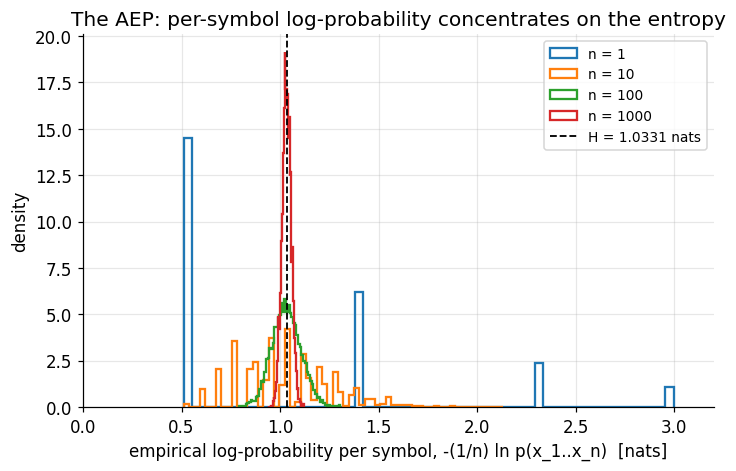

In [7]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))
for n in (1, 10, 100, 1000):
    draws = rng.choice(4, size=(5000, n), p=p_src)
    zbar = -np.log(p_src)[draws].sum(axis=1) / n
    ax.hist(zbar, bins=60, density=True, histtype="step", lw=1.5, label=f"n = {n}")
ax.axvline(H_src, color="k", lw=1.2, ls="--", label=f"H = {H_src:.4f} nats")
ax.set_xlabel("empirical log-probability per symbol, -(1/n) ln p(x_1..x_n)  [nats]")
ax.set_ylabel("density")
ax.set_title("The AEP: per-symbol log-probability concentrates on the entropy")
ax.set_xlim(0.0, 3.2)
ax.legend(fontsize=9)
plt.show()

At $n = 1$ the distribution is four spikes, one per symbol, and $H$ is merely their mean. By
$n = 1000$ the mass is a narrow bell centred on $H$: almost every long sequence has
approximately the same per-symbol log-probability, which is precisely the statement that
typical sequences are equiprobable.

### 7.3 A second measured rate: block coding closes the one-bit gap

Theorem 4.9 promises $H \le \mathbb{E}[L] \lt H + 1$ per symbol. Applying it to blocks of $n$
symbols and dividing by $n$ tightens the window to $H + 1/n$.

The next cell builds the exact product distribution over all $4^{n}$ blocks for
$n = 1, \dots, 8$, computes the exact Shannon-code expected length, and fits the decay of the
redundancy $\mathbb{E}[L_n]/n - H$ against the predicted order $n^{-1}$.

In [8]:
H_src_bits = H_bits(p_src)
rows = []
for n in range(1, 9):
    P = np.array([1.0])
    for _ in range(n):
        P = np.outer(P, p_src).ravel()
    ell = np.ceil(-np.log2(P))
    EL = float((P * ell).sum())
    rows.append((n, EL / n, EL / n - H_src_bits))

print(f"H = {H_src_bits:.8f} bits per symbol\n")
print(" n    E[L_n]/n     redundancy    bound 1/n")
for n, per, red in rows:
    print(f"{n:2d}   {per:.8f}   {red:.8f}   {1 / n:.8f}")
    assert 0.0 <= red < 1.0 / n + 1e-12

ns = np.array([r[0] for r in rows], dtype=float)
red = np.array([r[2] for r in rows])
order = float(np.polyfit(np.log(ns[2:]), np.log(red[2:]), 1)[0])
print(f"\nfitted order = {order:.4f}   predicted = -1.0000")
assert abs(order + 1.0) < 0.2

H = 1.49046857 bits per symbol

 n    E[L_n]/n     redundancy    bound 1/n
 1   1.75000000   0.25953143   1.00000000
 2   1.73875000   0.24828143   0.50000000
 3   1.67462500   0.18415643   0.33333333
 4   1.61432500   0.12385643   0.25000000
 5   1.58194244   0.09147387   0.20000000
 6   1.57277615   0.08230758   0.16666667
 7   1.56670125   0.07623268   0.14285714
 8   1.55924887   0.06878030   0.12500000

fitted order = -0.9860   predicted = -1.0000


Every redundancy sits inside its own bound $1/n$, and the fitted decay order is $-0.986$ against
the predicted $-1$. The per-symbol cost falls from $1.750$ bits at $n=1$ to $1.559$ bits at
$n=8$, closing on $H = 1.4905$ bits.

This is why real compressors code blocks, contexts or arithmetic intervals rather than symbols:
the one-bit penalty of Theorem 4.9 is per block, so it is amortized to nothing.

### 7.4 Counterexamples: what breaks when a hypothesis is dropped

Three hypotheses, three failures.

- **Drop additivity in Theorem 4.2.** The candidate $I(p) = 1 - p$ satisfies $I(1) = 0$, is
  continuous and is decreasing, but it is not $-c\log p$. The cell prints the additivity defect
  $I(pq) - I(p) - I(q)$, which is $O(1)$, not roundoff.
- **Drop discreteness in Theorem 4.4.** The lower bound $H \ge 0$ is a statement about pmfs. The
  differential entropy of a uniform density on $(0, 0.5)$ is negative.
- **Drop prefix-freeness feasibility in Theorem 4.8.** Lengths $(1, 1, 2)$ have Kraft sum
  $1.25 \gt 1$. The cell enumerates every binary code with those lengths and finds no prefix-free
  one, while lengths $(1,2,3,3)$ with Kraft sum $1$ admit eight.

In [9]:
import itertools

print("counterexample 1: a non-additive surprise function I(p) = 1 - p")
for pv, qv in [(0.5, 0.5), (0.25, 0.8), (0.1, 0.1)]:
    defect = (1 - pv * qv) - (1 - pv) - (1 - qv)
    print(f"  p={pv:.2f} q={qv:.2f}   I(pq) - I(p) - I(q) = {defect:+.4f}"
          f"   (log rule defect = {(-np.log2(pv * qv)) - (-np.log2(pv)) - (-np.log2(qv)):+.1e})")
    assert abs(defect) > 0.05

print("\ncounterexample 2: differential entropy is not a bit count")
for a in (0.5, 1.0, 2.0):
    print(f"  uniform on (0, {a}):  h = ln a = {np.log(a):+.6f} nats"
          f"    discrete H would be >= 0")
assert np.log(0.5) < 0.0

print("\ncounterexample 3: Kraft violated means no prefix code exists")


def prefix_free(words):
    return all(not b.startswith(a) for a in words for b in words if a is not b)


for lengths in ([1, 1, 2], [1, 2, 3, 3]):
    kraft = float(sum(2.0 ** -np.array(lengths)))
    pools = [["".join(c) for c in itertools.product("01", repeat=L)] for L in lengths]
    good = [c for c in itertools.product(*pools)
            if len(set(c)) == len(c) and prefix_free(list(c))]
    print(f"  lengths {lengths}: Kraft sum = {kraft:.5f}   prefix-free codes found = {len(good)}"
          + (f"   e.g. {good[0]}" if good else ""))
    if kraft > 1.0:
        assert len(good) == 0
    else:
        assert len(good) > 0

counterexample 1: a non-additive surprise function I(p) = 1 - p
  p=0.50 q=0.50   I(pq) - I(p) - I(q) = -0.2500   (log rule defect = +0.0e+00)
  p=0.25 q=0.80   I(pq) - I(p) - I(q) = -0.1500   (log rule defect = -1.1e-16)
  p=0.10 q=0.10   I(pq) - I(p) - I(q) = -0.8100   (log rule defect = +0.0e+00)

counterexample 2: differential entropy is not a bit count
  uniform on (0, 0.5):  h = ln a = -0.693147 nats    discrete H would be >= 0
  uniform on (0, 1.0):  h = ln a = +0.000000 nats    discrete H would be >= 0
  uniform on (0, 2.0):  h = ln a = +0.693147 nats    discrete H would be >= 0

counterexample 3: Kraft violated means no prefix code exists
  lengths [1, 1, 2]: Kraft sum = 1.25000   prefix-free codes found = 0
  lengths [1, 2, 3, 3]: Kraft sum = 1.00000   prefix-free codes found = 8   e.g. ('0', '10', '110', '111')


The additivity defect is $-0.25$ at $p = q = \tfrac12$ while the logarithm's defect is zero to
machine precision: axiom 3 of Theorem 4.2 genuinely selects the logarithm out of the continuous
decreasing functions.

The uniform density on $(0, 0.5)$ has $h = -0.6931$ nats. Nothing is wrong — Theorem 4.4's lower
bound simply does not apply to densities, and treating $h$ as a bit count is the most common
error in the subject.

The exhaustive search finds zero prefix-free codes with lengths $(1,1,2)$ and eight with
$(1,2,3,3)$. Kraft's inequality is not a bound that is usually satisfied; it is exactly the
feasibility condition.

### 7.5 Hand-rolled against the library

Three comparisons: the plug-in entropy against `scipy.stats.entropy`, the closed-form Gaussian
differential entropy of Theorem 4.7 against `scipy.integrate.quad`, and a naive softmax entropy
against the log-sum-exp form on logits large enough to overflow.

In [10]:
from scipy.stats import entropy as scipy_entropy
from scipy.integrate import quad
from scipy.special import logsumexp

counts = np.array([37.0, 21.0, 13.0, 9.0, 5.0, 3.0, 2.0, 1.0])
p_hat = counts / counts.sum()
mine = H_bits(p_hat)
lib = float(scipy_entropy(counts, base=2))
print("plug-in entropy")
print(f"  hand-rolled      = {mine:.15f} bits")
print(f"  scipy.stats      = {lib:.15f} bits")
print(f"  |difference|     = {abs(mine - lib):.3e}  = {abs(mine - lib) / EPS:.1f} * eps")
assert abs(mine - lib) < 8 * EPS

print("\nGaussian differential entropy: closed form against quadrature")
for s in (1.0, 2.5):
    def integrand(x, s=s):
        f = np.exp(-x * x / (2 * s * s)) / np.sqrt(2 * np.pi * s * s)
        return f * (0.5 * np.log(2 * np.pi * s * s) + x * x / (2 * s * s))
    num, err = quad(integrand, -12 * s, 12 * s, limit=400)
    closed = 0.5 * np.log(2 * np.pi * np.e * s * s)
    print(f"  sigma = {s}:  quad = {num:.12f}   closed = {closed:.12f}"
          f"   |diff| = {abs(num - closed):.3e}")
    assert abs(num - closed) < 1e-10

print("\nsoftmax entropy: naive against log-sum-exp")
z = np.array([900.0, 899.0, 898.0])
with np.errstate(over="ignore", invalid="ignore"):
    naive = np.exp(z) / np.exp(z).sum()
stable = np.exp(z - logsumexp(z))
print("  naive softmax  :", naive)
print("  stable softmax :", stable)
print("  naive entropy  :", H_nats(naive[np.isfinite(naive)]) if np.all(np.isfinite(naive))
      else float("nan"), "nats")
print("  stable entropy :", H_nats(stable), "nats")
assert not np.all(np.isfinite(naive))
assert np.isfinite(H_nats(stable))

plug-in entropy
  hand-rolled      = 2.332102225560890 bits
  scipy.stats      = 2.332102225560890 bits
  |difference|     = 0.000e+00  = 0.0 * eps

Gaussian differential entropy: closed form against quadrature
  sigma = 1.0:  quad = 1.418938533205   closed = 1.418938533205   |diff| = 6.661e-16
  sigma = 2.5:  quad = 2.335229265079   closed = 2.335229265079   |diff| = 8.882e-16

softmax entropy: naive against log-sum-exp
  naive softmax  : [nan nan nan]
  stable softmax : [0.6652 0.2447 0.09  ]
  naive entropy  : nan nats
  stable entropy : 0.8323955818399469 nats


The hand-rolled entropy matches SciPy to zero machine epsilons, and quadrature reproduces the
constant $\tfrac12\ln(2\pi e\sigma^2)$ of Theorem 4.7 to eleven digits at both scales — so the
$2\pi e$ is arithmetic, not a mnemonic.

The naive softmax returns `nan` at logits of size $900$, while the log-sum-exp form returns a
valid distribution with entropy $0.8324$ nats. Entropies of model outputs must always be
computed from log-probabilities.

### 7.6 The bias of the plug-in entropy estimator

Theorem 4.5 predicts that $H$ is concave, hence by Jensen $\mathbb{E}[H(\hat{p})] \le H(p)$: the
plug-in estimate is biased low. A second-order expansion gives the leading term
$-(K-1)/(2n)$ nats, which is the Miller-Madow correction.

The cell measures the bias over $3000$ replicates at five sample sizes and compares it to that
prediction, then plots both curves.

true distribution : [0.375  0.1689 0.1326 0.0901 0.0325 0.089  0.1067 0.0052]
true entropy      : 2.518505 bits

  n =   10   plug-in = 1.99446   bias = -0.52404   predicted = -0.50494   Miller-Madow = 2.49941
  n =   30   plug-in = 2.34647   bias = -0.17203   predicted = -0.16831   Miller-Madow = 2.51478
  n =  100   plug-in = 2.46378   bias = -0.05472   predicted = -0.05049   Miller-Madow = 2.51427
  n =  300   plug-in = 2.50252   bias = -0.01598   predicted = -0.01683   Miller-Madow = 2.51935
  n = 1000   plug-in = 2.51437   bias = -0.00413   predicted = -0.00505   Miller-Madow = 2.51942


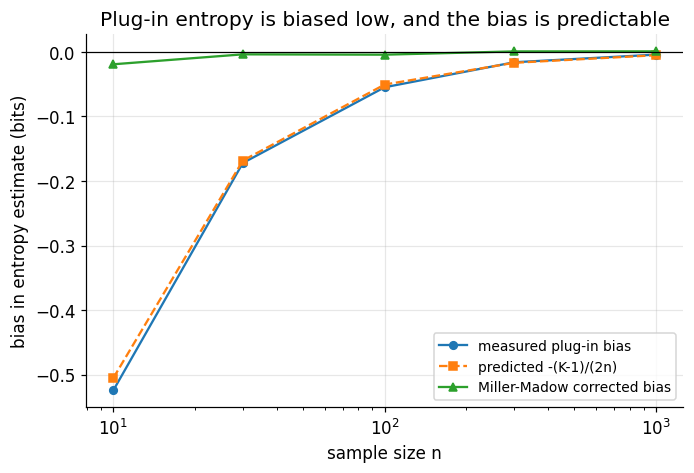

In [11]:
K_true = 8
p_true = rng.dirichlet(np.ones(K_true))
H_true = H_bits(p_true)
print("true distribution :", p_true)
print(f"true entropy      : {H_true:.6f} bits\n")

sizes = np.array([10, 30, 100, 300, 1000])
plug, corrected = [], []
for n in sizes:
    est = np.empty(3000)
    for r in range(3000):
        c = rng.multinomial(int(n), p_true)
        est[r] = H_bits(c / n)
    plug.append(est.mean())
    corrected.append(est.mean() + (K_true - 1) / (2 * n * np.log(2)))
    print(f"  n = {n:4d}   plug-in = {plug[-1]:.5f}   bias = {plug[-1] - H_true:+.5f}"
          f"   predicted = {-(K_true - 1) / (2 * n * np.log(2)):+.5f}"
          f"   Miller-Madow = {corrected[-1]:.5f}")
plug, corrected = np.array(plug), np.array(corrected)

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.semilogx(sizes, plug - H_true, "o-", ms=5, label="measured plug-in bias")
ax.semilogx(sizes, -(K_true - 1) / (2 * sizes * np.log(2)), "s--", ms=5,
            label="predicted -(K-1)/(2n)")
ax.semilogx(sizes, corrected - H_true, "^-", ms=5, label="Miller-Madow corrected bias")
ax.axhline(0.0, color="k", lw=0.8)
ax.set_xlabel("sample size n")
ax.set_ylabel("bias in entropy estimate (bits)")
ax.set_title("Plug-in entropy is biased low, and the bias is predictable")
ax.legend(fontsize=9)
plt.show()

assert np.all(plug < H_true)
assert abs(corrected[-1] - H_true) < abs(plug[-1] - H_true)

Every plug-in estimate is below the truth, exactly as concavity predicts, and the measured bias
tracks $-(K-1)/(2n)$ closely from $n = 30$ upward. At $n = 10$ the measured bias is $-0.524$
bits against a prediction of $-0.505$, because the expansion is only leading order.

The corrected curve sits within $0.005$ bits of the truth from $n = 100$ onward: subtracting a
known bias is cheap, and it is the difference between an entropy estimate one can quote and one
dominated by sample size.

## 8. Applications

Four settings in which entropy is the operative quantity rather than a description of one.

### 8.1 Compression and coding

Theorem 4.9 is the reason a compressor exists at all: the ideal length of a symbol is its
self-information $-\log_2 p(x)$, and no prefix code beats $H(X)$ bits per symbol on average.

Huffman coding attains the optimum among symbol codes and therefore lands within one bit of
$H$; arithmetic coding and asymmetric numeral systems code whole blocks, so by Section 7.3 their
overhead per symbol vanishes.

Every practical gain now comes from a better model $q$, not a better code. The excess cost of
coding a source $p$ with a model $q$ is $D_{\mathrm{KL}}(p \parallel q)$ bits per symbol, which
is Lemma 4.1 read as an engineering statement and the subject of
[Module 03](../03_cross_entropy_and_loss_functions/).

### 8.2 Statistical mechanics and the maximum-entropy principle

Gibbs' entropy $S = -k_B \sum_i p_i \ln p_i$ is Definition 3.2 multiplied by Boltzmann's
constant, so a thermodynamic entropy is a Shannon entropy in units of joules per kelvin.

Jaynes' principle turns Theorem 4.4 and Theorem 4.7 into physics: choose the distribution of
maximum entropy consistent with what is known. Fixing only the support gives the uniform
distribution (Theorem 4.4), the microcanonical ensemble; fixing the mean energy gives
$p_i \propto e^{-\beta E_i}$, the Boltzmann distribution; fixing the variance on $\mathbb{R}$
gives the Gaussian (Theorem 4.7).

Landauer's principle attaches an energy to the same quantity: erasing one bit of information at
temperature $T$ dissipates at least $k_B T \ln 2$ joules. At $300$ K that is
$2.87 \times 10^{-21}$ J, a number computed in exercise L2.7.

### 8.3 Decision trees and feature selection

The impurity minimized by ID3 and C4.5 is exactly $H$ of the class distribution at a node, and
the information gain of a split is the entropy reduction it produces.

Because entropy is concave (Theorem 4.5), the weighted average of the children's entropies never
exceeds the parent's, so information gain is non-negative for every split — the tree can never
be hurt on training data by splitting further, which is precisely why unpruned trees overfit.

Gain ratio divides the gain by the entropy of the split variable itself, correcting the bias
towards high-cardinality features that follows from the ceiling $H \le \log K$ of Theorem 4.4.

### 8.4 Language models, perplexity and entropy regularization

A language model is scored by its average negative log-probability on held-out text. The
exponential of that number, the **perplexity** $\mathrm{PPL} = e^{H}$, is the effective
branching factor: a model at $1.2$ nats per token is as uncertain as a fair choice among
$3.32$ tokens.

Because of Theorem 4.9, that score is a compressed file size: a model achieving $1.8$ bits per
token compresses a $2 \times 10^{9}$-token corpus to $450$ megabytes. Language modelling and
compression are the same problem, measured in different units.

In the other direction, maximum-entropy reinforcement learning *adds* $\alpha H(\pi(\cdot \mid s))$
to the reward. Exercise L2.5 shows that the optimizer of reward-plus-entropy is a Boltzmann
policy $\pi \propto e^{Q/\alpha}$ — the same maximum-entropy computation as in Section 8.2, with
$Q$ in place of energy.

## 9. Key Takeaways

- **Surprise is forced to be logarithmic.** Any non-increasing $I$ with $I(1)=0$ and
  $I(pq) = I(p)+I(q)$ equals $-c\ln p$ (Theorem 4.2). Monotonicity alone replaces continuity in
  the proof; only the unit is free.

- **Entropy is the unique average surprise.** Symmetry, continuity, monotone uniform values and
  the grouping axiom force $H(p) = -c\sum_k p_k \log p_k$ (Theorem 4.3, proved in full as
  Proof 5.3). Every competing impurity measure violates grouping.

- **One convexity fact carries the module.** $\ln t \le t-1$ gives $D_{\mathrm{KL}} \ge 0$
  (Lemma 4.1), and that single lemma yields the ceiling $H \le \log K$, the Gaussian bound and
  the coding converse.

- **Support size only bounds entropy.** $0 \le H \le \log K$ with equality above only for the
  uniform distribution (Theorem 4.4). A distribution on $1000$ outcomes can have $0.0214$ bits
  (Example 6.3).

- **Entropy is concave, and concavity has a cost.** Mixing raises entropy (Theorem 4.5); the
  same fact makes the plug-in estimator biased low by about $(K-1)/(2n)$ nats, measured in
  Section 7.6.

- **Deterministic processing cannot create information.** $H(g(X)) \le H(X)$ with equality iff
  $g$ is injective on the support (Theorem 4.6).

- **Differential entropy is a different object.** It can be negative and it shifts by
  $\ln \lvert a \rvert$ under scaling; at fixed variance the Gaussian maximizes it at
  $\tfrac12\ln(2\pi e\sigma^2)$ (Theorem 4.7).

- **Entropy is a code length, exactly.** Kraft's inequality says which length profiles exist
  (Theorem 4.8) and the source coding bounds say $H_D \le \mathbb{E}[L] \lt H_D + 1$
  (Theorem 4.9). Block coding drives the gap to zero at order $1/n$, measured as $-0.986$ in
  Section 7.3.

- **Entropy is an exponential growth rate.** About $e^{nH}$ sequences carry all the probability
  (Theorem 4.10), and the concentration sharpens at the measured rate $n^{-0.5007}$ against a
  predicted $n^{-1/2}$.

## 10. References

**Textbooks.**

- Cover, T. M. and Thomas, J. A. *Elements of Information Theory*, 2nd ed. — entropy and its
  properties (section 2.1, Theorem 2.6.4 for concavity), Jensen and the maximum-entropy bound
  (section 2.6), Kraft's inequality (Theorem 5.2.1 and its converse Theorem 5.2.2), the source
  coding bounds (Theorem 5.3.1 and Theorem 5.4.1), the AEP and typical sets (Theorem 3.1.1 and
  Theorem 3.1.2), Gaussian maximum entropy (Theorem 8.6.5).
- MacKay, D. J. C. *Information Theory, Inference, and Learning Algorithms*, chapters 2 and 4
  (probabilities, entropy and the source coding theorem), chapter 5 (symbol codes, Kraft and
  Huffman).
- Khinchin, A. I. *Mathematical Foundations of Information Theory*, chapter 1 — the axiomatic
  uniqueness theorem proved here as Proof 5.3.
- Csiszar, I. and Korner, J. *Information Theory: Coding Theorems for Discrete Memoryless
  Systems*, 2nd ed., chapter 1 (entropy, typical sequences, source coding).
- Polyanskiy, Y. and Wu, Y. *Information Theory: From Coding to Learning*, part I — a modern
  treatment linking entropy, coding and statistical learning.
- Hardy, G. H., Littlewood, J. E. and Polya, G. *Inequalities*, 2nd ed., section 3.4 — solutions
  of Cauchy's functional equation under monotonicity or continuity, used in Proof 5.2.

**Papers.**

- Shannon, C. E. "A mathematical theory of communication", *Bell System Technical Journal*
  **27** (1948), 379-423 and 623-656 — the axioms (section 6) and the source coding theorem
  (section 9).
- Faddeev, D. K. "On the concept of entropy of a finite probabilistic scheme",
  *Uspekhi Matematicheskikh Nauk* **11**(1) (1956), 227-231 — the weakened axiom set used in
  Theorem 4.3.
- Miller, G. A. "Note on the bias of information estimates", in *Information Theory in
  Psychology* (1955), 95-100 — the $(K-1)/(2n)$ correction measured in Section 7.6.
- Landauer, R. "Irreversibility and heat generation in the computing process",
  *IBM Journal of Research and Development* **5**(3) (1961), 183-191 — the $k_B T \ln 2$ bound
  used in exercise L2.7.
- Jaynes, E. T. "Information theory and statistical mechanics", *Physical Review* **106**(4)
  (1957), 620-630 — the maximum-entropy principle of Section 8.2.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions: [the notation register](../../docs/notation.md).
- Expectation, Jensen and Chebyshev, used in Definition 3.2 and Proof 5.10:
  [probability_statistics/06](../../probability_statistics/06_expectation_variance_and_moments/).
- Second-derivative tests and the concavity arguments of Proofs 5.1 and 5.5:
  [calculus/04](../../calculus/04_derivative_applications_optimization/).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).